# Importando Bibliotecas

In [1]:
import os
try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir('aulas_teoricas')
except FileNotFoundError:
    pass

import logging

# 1. Silencia avisos da camada nativa (C++) do TensorFlow e subprocessos Python
# 0 = todos os logs, 1 = oculta INFO, 2 = oculta INFO e WARNING, 3 = oculta tudo (até ERROR do C++)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS'] = 'ignore'

# 2. Silencia avisos nativos do Python
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# 3. Silencia loggers do TensorFlow e Keras (deve vir logo após importar o TF)
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [45]:
# Carregamento de dados
from joblib import load, dump

# Processamento de dados
import pandas as pd
from util import utils as ut
import numpy as np

# Estatística
from scipy.stats import chi2_contingency
from scipy.stats import ks_2samp
# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Classificador 
from src.regression import Regression

# Importando Dados

In [3]:
# Verificando os arquivos no diretório 'data/df_estruturada'
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid']

In [4]:
# Importando os dados de treino
df_train = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_train"),
    load("./data/df_estruturada/08_aula_09_y_train")
], axis=1)
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia


In [5]:
# Importando os dados de treino
df_valid = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_valid"),
    load("./data/df_estruturada/08_aula_09_y_valid")
], axis=1)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer


In [6]:
# Importando os dados de treino
df_test = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_test"),
    load("./data/df_estruturada/08_aula_09_y_test")
], axis=1)
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia


# Validação cruzada e busca de hiperparâmetros

## Treino

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

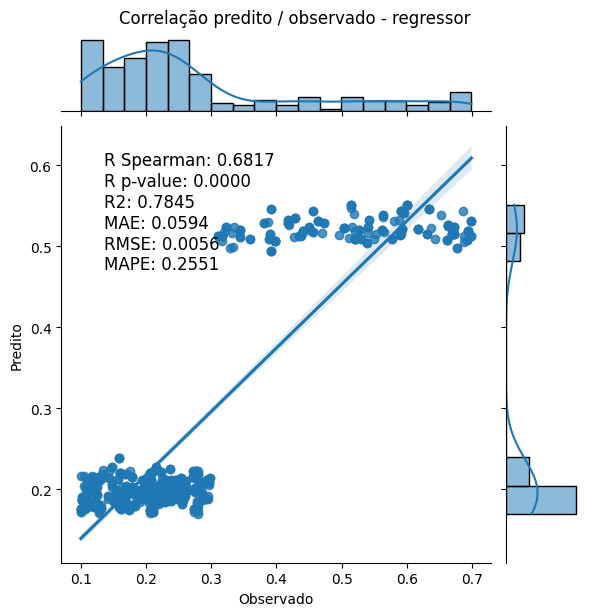

In [7]:
regressor = Regression(
    df=df_train
)

metricas_regr, pred_regr = regressor.regress(modelo='regressor')

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

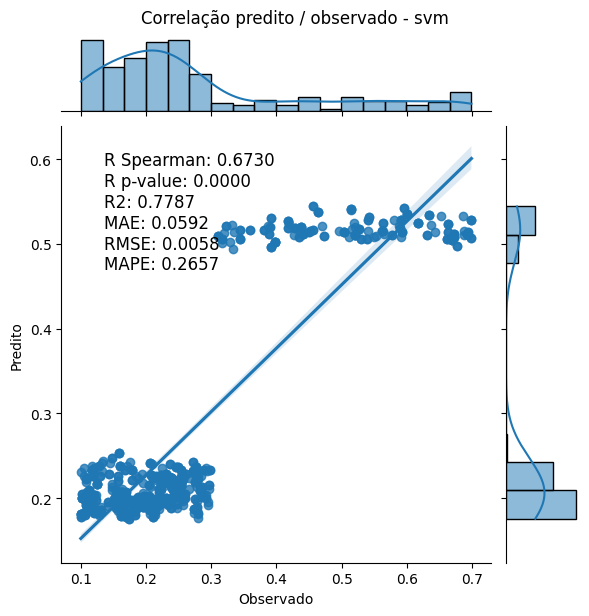

In [8]:
metricas_svm, pred_svm = regressor.regress(modelo='svm')

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

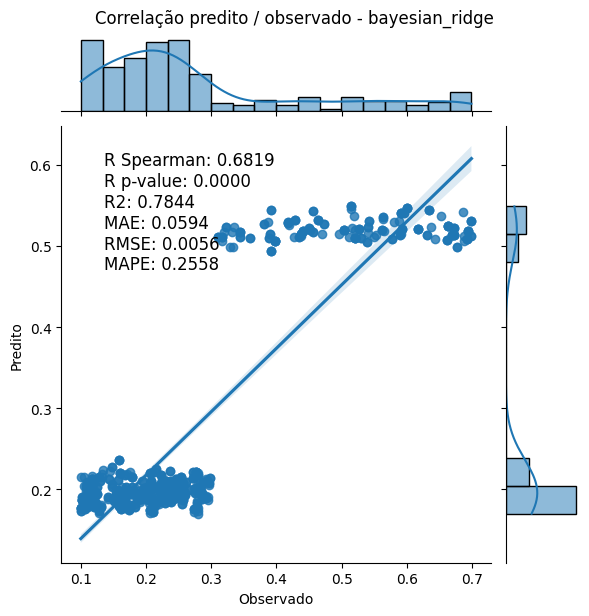

In [9]:
metricas_nb, pred_nb = regressor.regress(modelo='bayesian_ridge')

O cálculo do volume de treinos atual é:$$\underbrace{3}_{\text{threshold}} \times \underbrace{3}_{\text{k}} \times \underbrace{3}_{\text{optimizer}} \times \underbrace{2}_{\text{epochs}} \times \underbrace{3}_{\text{batch\_size}} \times \underbrace{4}_{\text{activation1}} \times \underbrace{4}_{\text{activation2}} = 2.592 \text{ combinações}$$Multiplicado pelos $5$ folds do Cross-Validation: $2.592 \times 5 = 12.960$ modelos sendo ajustados.

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

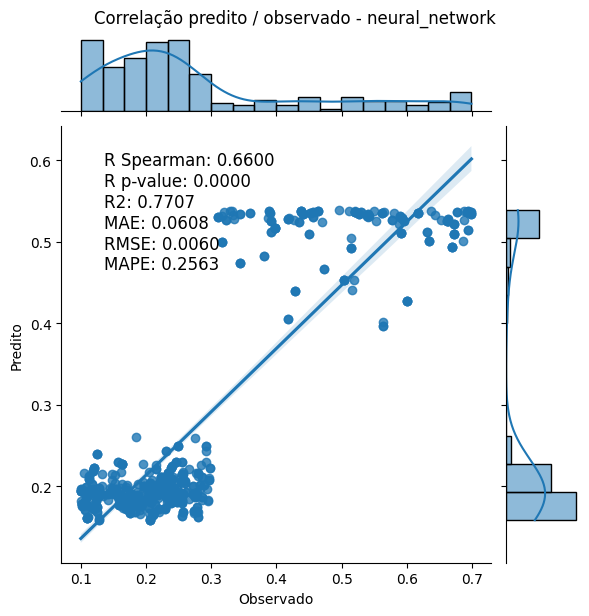

In [10]:
metricas_nn, pred_nn = regressor.regress(modelo='neural_network', n_iter_search=2)

In [11]:
try:
    metricas_estr, pred_estr = regressor.regress(modelo='Estrela')
except ValueError as e:
    print(e)

Modelo inválido: Estrela. Escolha 'regressor', 'svm', 'bayesian_ridge' ou 'neural_network'.


In [12]:
algoritmo_1 = 'Multiple Linear Regression'
algoritmo_2 = 'Suport Vector Machine'
algoritmo_3 = 'Nayve Bayes'
algoritmo_4 = 'Neural Network'

# Organizando as métricas de treinamento
df_metricas_train = pd.concat([
    metricas_regr.T.copy(),
    metricas_svm.T.copy(),
    metricas_nb.T.copy(),
    metricas_nn.T.copy(),
])
df_metricas_train.reset_index(inplace=True)
df_metricas_train['modelo'] = [algoritmo_1]*6 + [algoritmo_2]*6 + [algoritmo_3]*6 + [algoritmo_4]*6
df_metricas_train.rename(columns={'index':'metricas', 0:'valores'}, inplace=True)
df_metricas_train.head()

,metricas,valores,modelo
0,R Spearman,0.6817,Multiple Linear Regression
1,R p-value,0.0000,Multiple Linear Regression
2,R2,0.7845,Multiple Linear Regression
3,MAE,0.0594,Multiple Linear Regression
4,RMSE,0.0056,Multiple Linear Regression


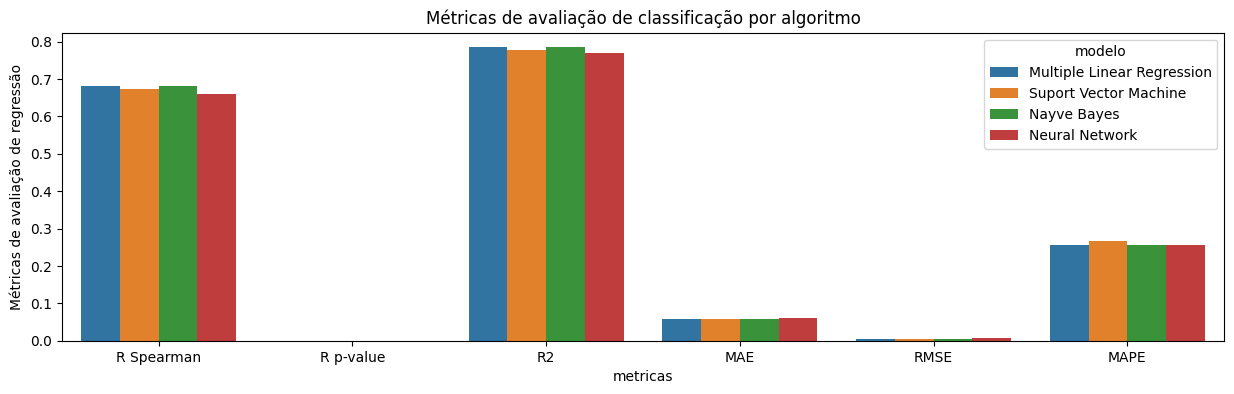

In [13]:
# Gráfico de barras das métricas de avaliação de regressão para os algoritmos
plt.figure(figsize=(15, 4))
plt.title('Métricas de avaliação de classificação por algoritmo')
p = sns.barplot(
    x='metricas',
    y='valores',
    hue='modelo',
    data=df_metricas_train,
)
plt.ylabel('Métricas')
plt.ylabel('Métricas de avaliação de regressão')

plt.show()

In [14]:
df_train[algoritmo_1] = pred_regr.copy()
df_train[algoritmo_2] = pred_svm.copy()
df_train[algoritmo_3] = pred_nb.copy()
df_train[algoritmo_4] = pred_nn.copy()

df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia,0.212639,0.226567,0.211931,0.188250
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia,0.222520,0.237118,0.221760,0.187915
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia,0.199940,0.202893,0.199446,0.198520
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia,0.213565,0.233628,0.212749,0.193436
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia,0.177484,0.192081,0.178101,0.160807


## Validação

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

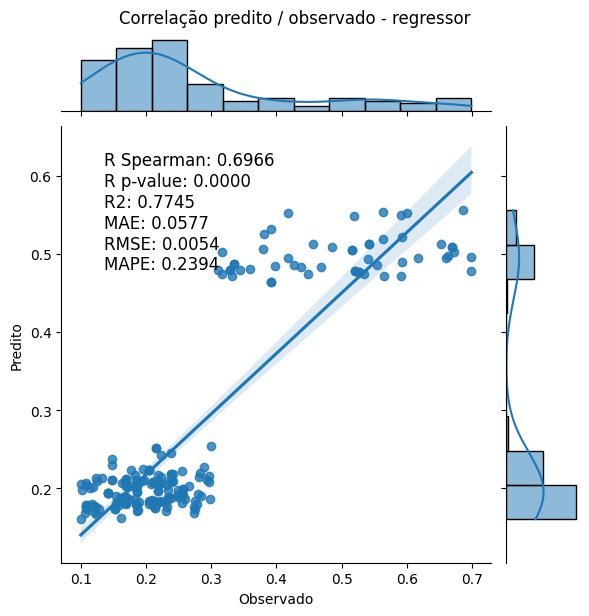

In [15]:
regressor = Regression(
    df=df_valid
)

metricas_regr, pred_regr = regressor.regress(modelo='regressor')

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

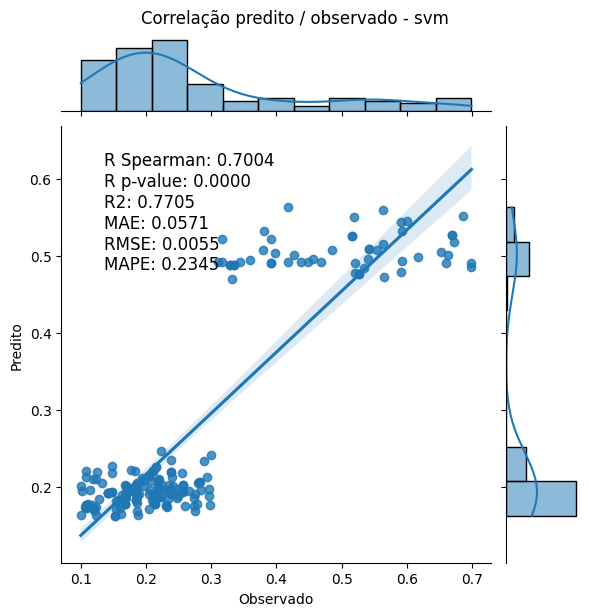

In [16]:
metricas_svm, pred_svm = regressor.regress(modelo='svm')

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

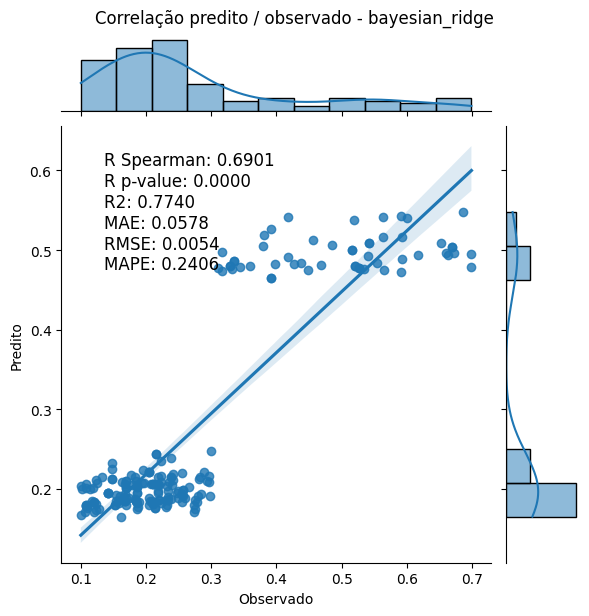

In [17]:
metricas_nb, pred_nb = regressor.regress(modelo='bayesian_ridge')

O cálculo do volume de treinos atual é:$$\underbrace{3}_{\text{threshold}} \times \underbrace{3}_{\text{k}} \times \underbrace{3}_{\text{optimizer}} \times \underbrace{2}_{\text{epochs}} \times \underbrace{3}_{\text{batch\_size}} \times \underbrace{4}_{\text{activation1}} \times \underbrace{4}_{\text{activation2}} = 2.592 \text{ combinações}$$Multiplicado pelos $5$ folds do Cross-Validation: $2.592 \times 5 = 12.960$ modelos sendo ajustados.

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__PPD_log
2. num__correlatas

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True              False
                  num__CD3_2              True              False
                    num__CD8              True              False
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True              False
          cat__classe_cancer              True              False
cat__classe_imunodeficiencia              True              False
        cat__classe_leucemia              True              False


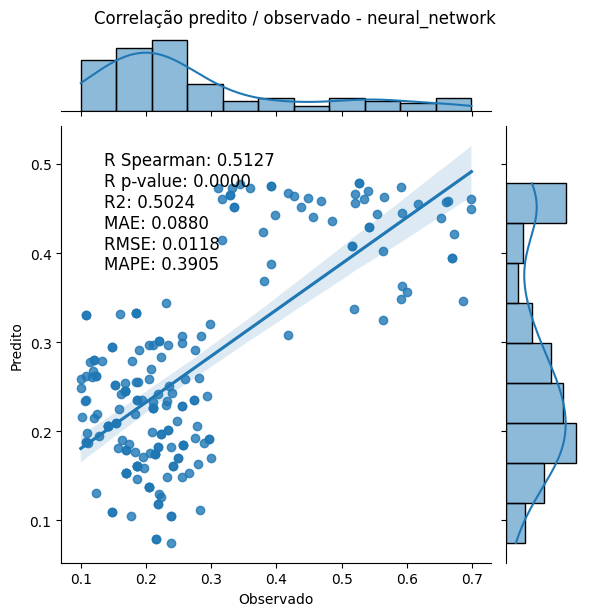

In [18]:
metricas_nn, pred_nn = regressor.regress(modelo='neural_network', n_iter_search=2)

In [19]:
try:
    metricas_estr, pred_estr = regressor.regress(modelo='Estrela')
except ValueError as e:
    print(e)

Modelo inválido: Estrela. Escolha 'regressor', 'svm', 'bayesian_ridge' ou 'neural_network'.


In [20]:
# Organizando as métricas de treinamento
df_metricas_valid = pd.concat([
    metricas_regr.T.copy(),
    metricas_svm.T.copy(),
    metricas_nb.T.copy(),
    metricas_nn.T.copy(),
])
df_metricas_valid.reset_index(inplace=True)
df_metricas_valid['modelo'] = [algoritmo_1]*6 + [algoritmo_2]*6 + [algoritmo_3]*6 + [algoritmo_4]*6
df_metricas_valid.rename(columns={'index':'metricas', 0:'valores'}, inplace=True)
df_metricas_valid.head()

,metricas,valores,modelo
0,R Spearman,0.6966,Multiple Linear Regression
1,R p-value,0.0000,Multiple Linear Regression
2,R2,0.7745,Multiple Linear Regression
3,MAE,0.0577,Multiple Linear Regression
4,RMSE,0.0054,Multiple Linear Regression


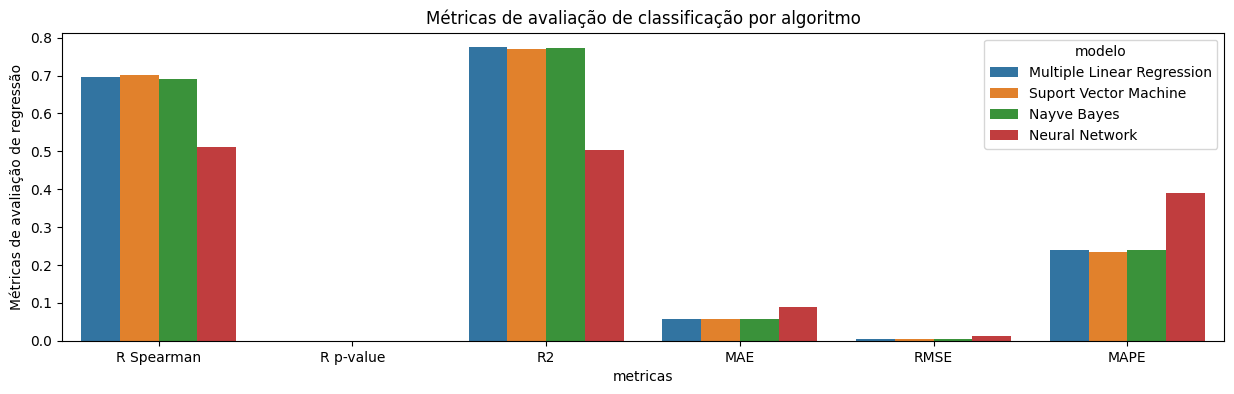

In [21]:
# Gráfico de barras das métricas de avaliação de regressão para os algoritmos
plt.figure(figsize=(15, 4))
plt.title('Métricas de avaliação de classificação por algoritmo')
p = sns.barplot(
    x='metricas',
    y='valores',
    hue='modelo',
    data=df_metricas_valid,
)
plt.ylabel('Métricas')
plt.ylabel('Métricas de avaliação de regressão')

plt.show()

In [22]:
df_valid[algoritmo_1] = pred_regr.copy()
df_valid[algoritmo_2] = pred_svm.copy()
df_valid[algoritmo_3] = pred_nb.copy()
df_valid[algoritmo_4] = pred_nn.copy()

df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia,0.179415,0.183538,0.184897,0.332570
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia,0.161601,0.164563,0.165370,0.241393
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer,0.237762,0.227644,0.233136,0.109316
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer,0.189585,0.181427,0.192926,0.208817
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer,0.223239,0.214776,0.221535,0.137654


## Teste

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

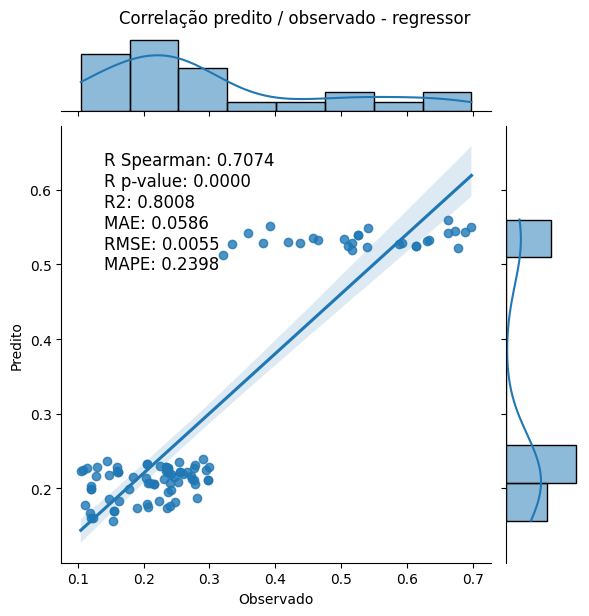

In [23]:
regressor = Regression(
    df=df_test
)

metricas_regr, pred_regr = regressor.regress(modelo='regressor')

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

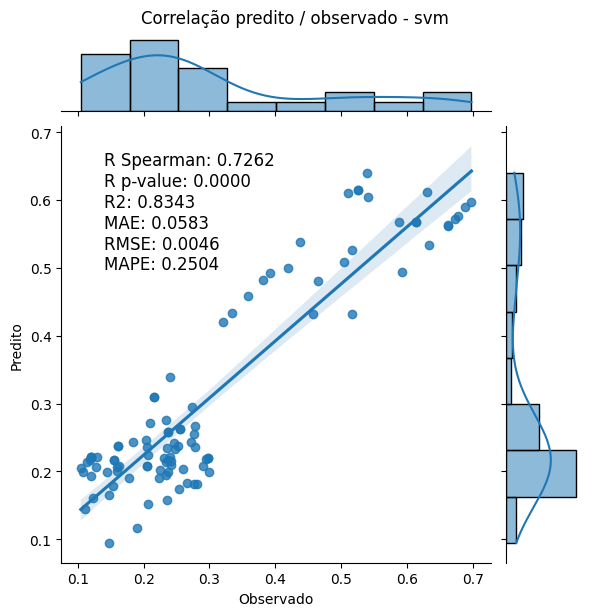

In [24]:
metricas_svm, pred_svm = regressor.regress(modelo='svm')

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

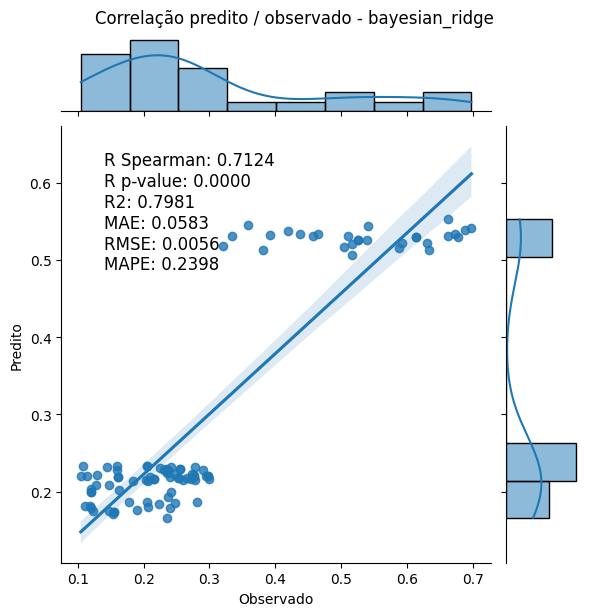

In [25]:
metricas_nb, pred_nb = regressor.regress(modelo='bayesian_ridge')

O cálculo do volume de treinos atual é:$$\underbrace{3}_{\text{threshold}} \times \underbrace{3}_{\text{k}} \times \underbrace{3}_{\text{optimizer}} \times \underbrace{2}_{\text{epochs}} \times \underbrace{3}_{\text{batch\_size}} \times \underbrace{4}_{\text{activation1}} \times \underbrace{4}_{\text{activation2}} = 2.592 \text{ combinações}$$Multiplicado pelos $5$ folds do Cross-Validation: $2.592 \times 5 = 12.960$ modelos sendo ajustados.

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

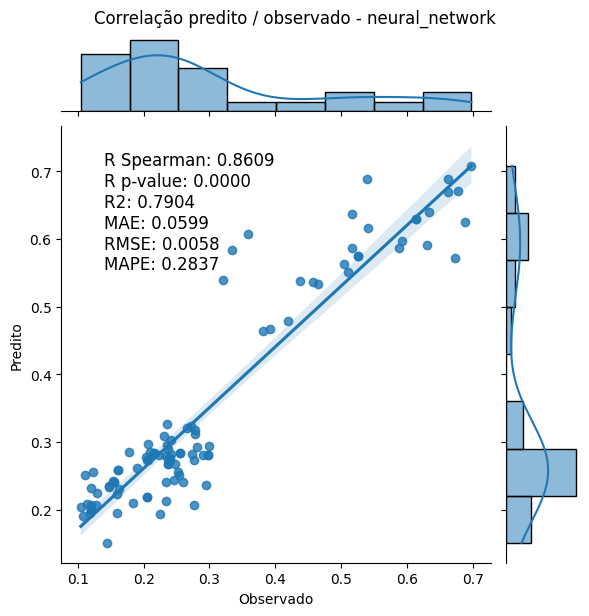

In [26]:
metricas_nn, pred_nn = regressor.regress(modelo='neural_network', n_iter_search=2)

In [27]:
try:
    metricas_estr, pred_estr = regressor.regress(modelo='Estrela')
except ValueError as e:
    print(e)

Modelo inválido: Estrela. Escolha 'regressor', 'svm', 'bayesian_ridge' ou 'neural_network'.


In [28]:
# Organizando as métricas de treinamento
df_metricas_test = pd.concat([
    metricas_regr.T.copy(),
    metricas_svm.T.copy(),
    metricas_nb.T.copy(),
    metricas_nn.T.copy(),
])
df_metricas_test.reset_index(inplace=True)
df_metricas_test['modelo'] = [algoritmo_1]*6 + [algoritmo_2]*6 + [algoritmo_3]*6 + [algoritmo_4]*6
df_metricas_test.rename(columns={'index':'metricas', 0:'valores'}, inplace=True)
df_metricas_test.head()

,metricas,valores,modelo
0,R Spearman,0.7074,Multiple Linear Regression
1,R p-value,0.0000,Multiple Linear Regression
2,R2,0.8008,Multiple Linear Regression
3,MAE,0.0586,Multiple Linear Regression
4,RMSE,0.0055,Multiple Linear Regression


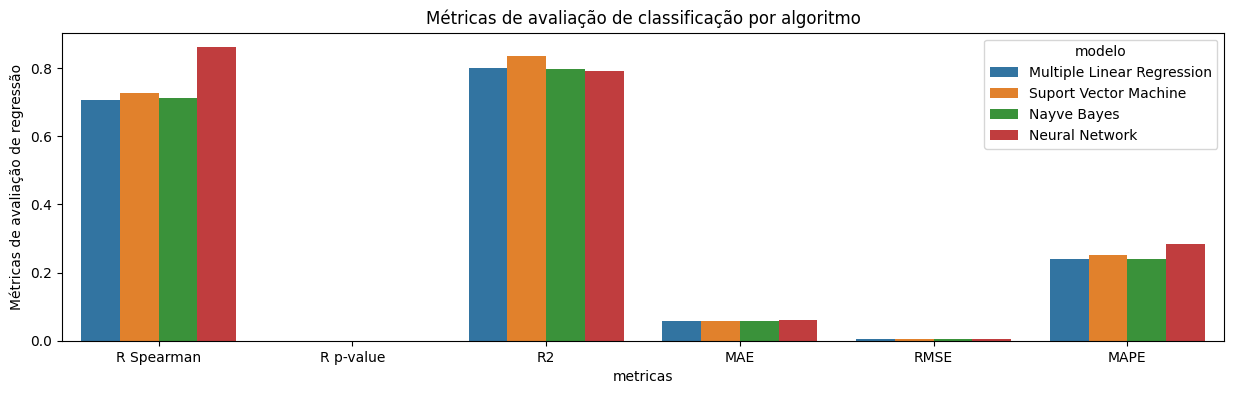

In [29]:
# Gráfico de barras das métricas de avaliação de regressão para os algoritmos
plt.figure(figsize=(15, 4))
plt.title('Métricas de avaliação de classificação por algoritmo')
p = sns.barplot(
    x='metricas',
    y='valores',
    hue='modelo',
    data=df_metricas_test,
)
plt.ylabel('Métricas')
plt.ylabel('Métricas de avaliação de regressão')

plt.show()

In [30]:
df_test[algoritmo_1] = pred_regr.copy()
df_test[algoritmo_2] = pred_svm.copy()
df_test[algoritmo_3] = pred_nb.copy()
df_test[algoritmo_4] = pred_nn.copy()

df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer,0.227496,0.258771,0.226350,0.266879
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia,0.177090,0.220806,0.178149,0.275713
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer,0.211997,0.294911,0.222489,0.281923
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer,0.214366,0.245954,0.215557,0.278114
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia,0.210735,0.220460,0.219586,0.280856


# Avalia Modelos

In [31]:
dump(df_train, "./data/08_aula_09_df_train_resultados_regression")
df_train = load("./data/08_aula_09_df_train_resultados_regression")

dump(df_valid, "./data/08_aula_09_df_valid_resultados_regression")
df_valid = load("./data/08_aula_09_df_valid_resultados_regression")

dump(df_test, "./data/08_aula_09_df_test_resultados_regression")
df_test = load("./data/08_aula_09_df_test_resultados_regression")

In [32]:
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia,0.212639,0.226567,0.211931,0.188250
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia,0.222520,0.237118,0.221760,0.187915
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia,0.199940,0.202893,0.199446,0.198520
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia,0.213565,0.233628,0.212749,0.193436
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia,0.177484,0.192081,0.178101,0.160807


In [33]:
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia,0.179415,0.183538,0.184897,0.332570
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia,0.161601,0.164563,0.165370,0.241393
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer,0.237762,0.227644,0.233136,0.109316
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer,0.189585,0.181427,0.192926,0.208817
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer,0.223239,0.214776,0.221535,0.137654


In [34]:
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer,0.227496,0.258771,0.226350,0.266879
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia,0.177090,0.220806,0.178149,0.275713
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer,0.211997,0.294911,0.222489,0.281923
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer,0.214366,0.245954,0.215557,0.278114
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia,0.210735,0.220460,0.219586,0.280856


In [43]:
def testar_hipotese(y_pred_treino: pd.Series, y_pred_teste: pd.Series) -> None:
    """
    Testa a hipótese de que a distribuição das classes no treino e no teste é estatisticamente igual (homogênea)
    ou diferente (heterogênea) usando o teste Qui-Quadrado.

    Parâmetros:
        y_pred_treino : pd.Series
            Série contendo as previsões do conjunto de treino.
        y_pred_teste : pd.Series
            Série contendo as previsões do conjunto de teste.
    Retorna:
        None
    """
    estatistica_D, valor_p = ks_2samp(y_pred_treino, y_pred_teste)

    # 3. Exibindo os resultados
    print("=== Resultados do Teste Kolmogorov-Smirnov ===")
    print(f"Estatística D: {estatistica_D:.4f}")
    print(f"Valor-p: {valor_p:.4f}")

    # 4. Interpretando com um nível de significância de 5% (0.05)
    alfa = 0.05

    print("\n--- Conclusão ---")
    if valor_p < alfa:
        print("Rejeitamos a Hipótese Nula (H0).")
        print("As distribuições das previsões de treino e teste são ESTATISTICAMENTE DIFERENTES.")
        print("Atenção: O modelo está gerando um padrão de resultados no teste diferente do treino.")
    else:
        print("Falhamos em rejeitar a Hipótese Nula (H0).")
        print("Não há evidências suficientes para dizer que as distribuições são diferentes.")
        print("As previsões de treino e teste são ESTATISTICAMENTE IGUAIS (mesma distribuição).")

    return None

In [55]:
c = -4
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")

testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]]
)



Testando a hipótese para o modelo: Multiple Linear Regression
=== Resultados do Teste Kolmogorov-Smirnov ===
Estatística D: 0.3414
Valor-p: 0.0000

--- Conclusão ---
Rejeitamos a Hipótese Nula (H0).
As distribuições das previsões de treino e teste são ESTATISTICAMENTE DIFERENTES.
Atenção: O modelo está gerando um padrão de resultados no teste diferente do treino.


In [56]:
c += 1
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")
testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]]
)



Testando a hipótese para o modelo: Suport Vector Machine
=== Resultados do Teste Kolmogorov-Smirnov ===
Estatística D: 0.1943
Valor-p: 0.0024

--- Conclusão ---
Rejeitamos a Hipótese Nula (H0).
As distribuições das previsões de treino e teste são ESTATISTICAMENTE DIFERENTES.
Atenção: O modelo está gerando um padrão de resultados no teste diferente do treino.


In [57]:
c += 1
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")

testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]]
)



Testando a hipótese para o modelo: Nayve Bayes
=== Resultados do Teste Kolmogorov-Smirnov ===
Estatística D: 0.4100
Valor-p: 0.0000

--- Conclusão ---
Rejeitamos a Hipótese Nula (H0).
As distribuições das previsões de treino e teste são ESTATISTICAMENTE DIFERENTES.
Atenção: O modelo está gerando um padrão de resultados no teste diferente do treino.


In [58]:
c += 1
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")

testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]]
)



Testando a hipótese para o modelo: Neural Network
=== Resultados do Teste Kolmogorov-Smirnov ===
Estatística D: 0.5429
Valor-p: 0.0000

--- Conclusão ---
Rejeitamos a Hipótese Nula (H0).
As distribuições das previsões de treino e teste são ESTATISTICAMENTE DIFERENTES.
Atenção: O modelo está gerando um padrão de resultados no teste diferente do treino.
